# **Importing the dependencies**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import math
from xgboost import plot_importance
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
bank_df=pd.read_excel('/content/drive/MyDrive/bank_data.xlsx')
cibil_df=pd.read_excel('/content/drive/MyDrive/cibil_data.xlsx')

In [ ]:
bank_df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0,0,1,0,4,1,4,0,72,18
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0,1,0,0,0,0,1,0,7,7
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0,6,1,0,0,2,6,0,47,2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0,0,0,0,0,0,1,1,5,5
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0,0,0,0,0,3,0,2,131,32


In [ ]:
cibil_df.head()

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549,35,15,11,29,29,0,0,0,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,47,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,302,11,3,9,25,25,1,9,8,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,-99999,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,583,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [ ]:
cibil_df[['CC_utilization','PL_utilization']].sample(10)

,CC_utilization,PL_utilization
23468,0.323,-99999.000
33477,-99999.000,-99999.000
22892,-99999.000,-99999.000
18137,-99999.000,-99999.000
41689,-99999.000,-99999.000
48482,-99999.000,-99999.000
29891,-99999.000,-99999.000
13409,-99999.000,-99999.000
10363,-99999.000,-99999.000
34332,-99999.000,0.127


In [ ]:
print(bank_df.shape)
print(cibil_df.shape)

(51336, 26)
(51336, 62)


In [ ]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PROSPECTID            51336 non-null  int64  
 1   Total_TL              51336 non-null  int64  
 2   Tot_Closed_TL         51336 non-null  int64  
 3   Tot_Active_TL         51336 non-null  int64  
 4   Total_TL_opened_L6M   51336 non-null  int64  
 5   Tot_TL_closed_L6M     51336 non-null  int64  
 6   pct_tl_open_L6M       51336 non-null  float64
 7   pct_tl_closed_L6M     51336 non-null  float64
 8   pct_active_tl         51336 non-null  float64
 9   pct_closed_tl         51336 non-null  float64
 10  Total_TL_opened_L12M  51336 non-null  int64  
 11  Tot_TL_closed_L12M    51336 non-null  int64  
 12  pct_tl_open_L12M      51336 non-null  float64
 13  pct_tl_closed_L12M    51336 non-null  float64
 14  Tot_Missed_Pmnt       51336 non-null  int64  
 15  Auto_TL            

In [ ]:
cibil_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   time_since_recent_payment     51336 non-null  int64  
 2   time_since_first_deliquency   51336 non-null  int64  
 3   time_since_recent_deliquency  51336 non-null  int64  
 4   num_times_delinquent          51336 non-null  int64  
 5   max_delinquency_level         51336 non-null  int64  
 6   max_recent_level_of_deliq     51336 non-null  int64  
 7   num_deliq_6mts                51336 non-null  int64  
 8   num_deliq_12mts               51336 non-null  int64  
 9   num_deliq_6_12mts             51336 non-null  int64  
 10  max_deliq_6mts                51336 non-null  int64  
 11  max_deliq_12mts               51336 non-null  int64  
 12  num_times_30p_dpd             51336 non-null  int64  
 13  n

In [ ]:
(bank_df.isin([-99999]).any(axis=1)).sum()

40

In [ ]:
bank_df[bank_df.isin([-99999]).any(axis=1)]

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
532,533,2,2,0,0,0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,2,0,2,-99999,-99999
804,805,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999
1179,1180,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,1,0,0,1,0,0,-99999,-99999
3299,3300,1,1,0,0,0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,1,1,-99999,-99999
5694,5695,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999
5951,5952,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999
9079,9080,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999
10003,10004,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999
10859,10860,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,1,0,1,-99999,-99999
12017,12018,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999


In [ ]:
bank_df = bank_df[~bank_df.isin([-99999]).any(axis=1)]

In [ ]:
bank_df.shape

(51296, 26)

In [ ]:
(cibil_df.isin([-99999]).any(axis=1)).sum()

50751

In [ ]:
cibil_df.replace(-99999, np.nan, inplace=True)

In [ ]:
#getting the columns with (-99999) as a value
counts = cibil_df.isna().sum()
print(counts[counts > 0])

time_since_recent_payment        4291
time_since_first_deliquency     35949
time_since_recent_deliquency    35949
max_delinquency_level           35949
max_deliq_6mts                  12890
max_deliq_12mts                 10832
tot_enq                          6321
CC_enq                           6321
CC_enq_L6m                       6321
CC_enq_L12m                      6321
PL_enq                           6321
PL_enq_L6m                       6321
PL_enq_L12m                      6321
time_since_recent_enq            6321
enq_L12m                         6321
enq_L6m                          6321
enq_L3m                          6321
pct_currentBal_all_TL              72
CC_utilization                  47636
PL_utilization                  44435
max_unsec_exposure_inPct        23178
dtype: int64


In [ ]:
cibil_df.head()

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549.0,35.0,15.0,11,29.0,29,0,0,0,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,47.0,NaN,NaN,0,NaN,0,0,0,0,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,302.0,11.0,3.0,9,25.0,25,1,9,8,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,NaN,NaN,NaN,0,NaN,0,0,0,0,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,583.0,NaN,NaN,0,NaN,0,0,0,0,...,0.0,0.0,0.0,NaN,0,0,AL,AL,753,P1


In [ ]:
# Checking common column names
for i in list(bank_df.columns):
    if i in list(cibil_df.columns):
        print (i)

PROSPECTID


In [ ]:
# Merging the two dataframes, inner join so that no nulls are present
df = pd.merge(bank_df,cibil_df, how ='inner', left_on = ['PROSPECTID'], right_on = ['PROSPECTID'])

In [ ]:
df.shape

(51296, 87)

In [ ]:
corr_matrix = df.corr(numeric_only=True)
pd.set_option('display.max_rows', None)
corr_target = corr_matrix['Credit_Score'].sort_values(ascending=False)
print(corr_target)
pd.reset_option('display.max_rows')

Credit_Score                    1.000000
Age_Oldest_TL                   0.533830
num_std_12mts                   0.470456
num_std                         0.464342
num_std_6mts                    0.441984
time_since_recent_enq           0.374473
AGE                             0.272726
Other_TL                        0.258262
Secured_TL                      0.223467
Tot_Closed_TL                   0.206734
Total_TL                        0.202970
pct_closed_tl                   0.182872
Time_With_Curr_Empr             0.176965
Home_TL                         0.168316
HL_Flag                         0.162555
GL_Flag                         0.149821
Auto_TL                         0.149083
Gold_TL                         0.129447
Age_Newest_TL                   0.102662
Tot_Active_TL                   0.099685
time_since_recent_payment       0.099274
Tot_TL_closed_L12M              0.083414
PL_TL                           0.078896
Tot_Missed_Pmnt                 0.075544
num_sub         

In [ ]:
target=df[['Credit_Score','Approved_Flag']]
target.shape

(51296, 2)

In [ ]:
target.sample(10)

,Credit_Score,Approved_Flag
9930,688,P2
1013,688,P2
46964,677,P2
48683,670,P2
1449,667,P3
43282,688,P2
48208,671,P2
20060,665,P3
36064,723,P1
47643,690,P2


In [ ]:
df['Approved_Flag'].value_counts()

,count
Approved_Flag,
P2,32162
P3,7449
P4,5882
P1,5803


In [ ]:
df=df.drop(columns=['PROSPECTID','Credit_Score','Approved_Flag','pct_of_active_TLs_ever'])
df.shape

(51296, 83)

In [ ]:
target.describe()

,Credit_Score
count,51296.000000
mean,679.856188
std,20.508480
min,469.000000
25%,669.000000
50%,680.000000
75%,690.250000
max,811.000000


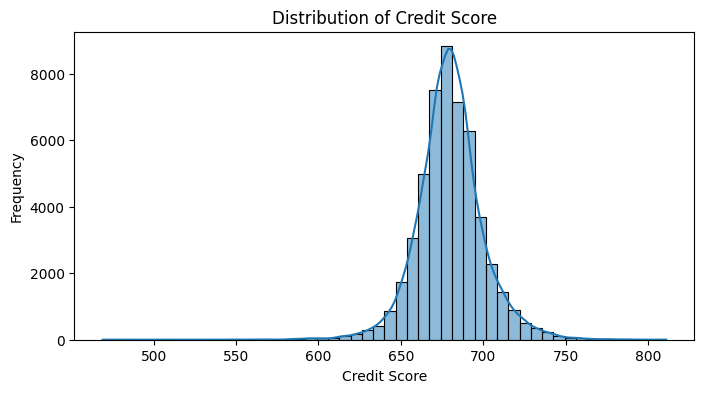

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(target['Credit_Score'],kde=True,bins=50)
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
print("Skewness:%.2f"%target['Credit_Score'].skew())
print("Kurtosis:%.2f"%target['Credit_Score'].kurtosis())

Skewness:-0.11
Kurtosis:3.95


# **Baseline Model**

In [ ]:
X = df  # cleaned feature set (after dropping leakage columns)
y = target['Credit_Score']  # your target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Baseline prediction = mean of y_train
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

# Step 3: Evaluate
mae = mean_absolute_error(y_test, baseline_pred)
rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
r2 = r2_score(y_test, baseline_pred)

print(f"Baseline MAE  : {mae:.2f}")
print(f"Baseline RMSE : {rmse:.2f}")
print(f"Baseline R²   : {r2:.4f}")

Baseline MAE  : 14.63
Baseline RMSE : 20.13
Baseline R²   : -0.0001


In [ ]:
X = df[['Age_Oldest_TL']]  # must be a 2D array
y = target['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 12.57
RMSE : 16.94
R²   : 0.2912


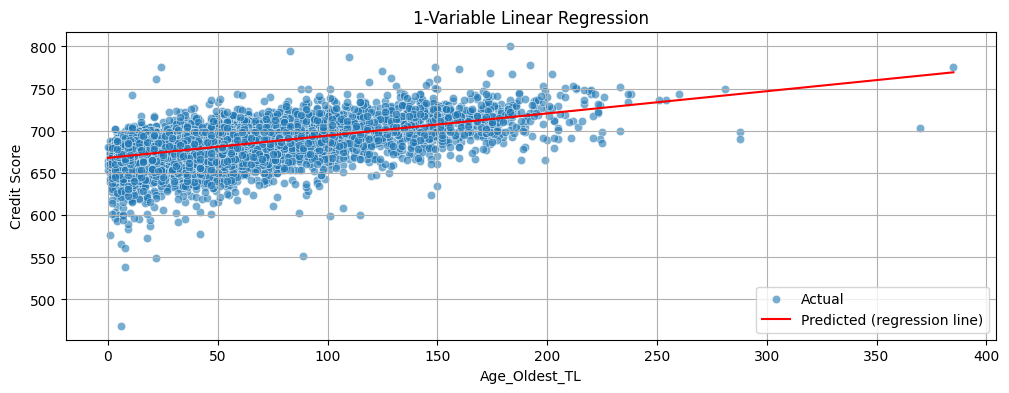

In [ ]:
plt.figure(figsize=(12,4))
sns.scatterplot(x=X_test['Age_Oldest_TL'], y=y_test, label='Actual', alpha=0.6)
sns.lineplot(x=X_test['Age_Oldest_TL'], y=y_pred, color='red', label='Predicted (regression line)')
plt.xlabel('Age_Oldest_TL')
plt.ylabel('Credit Score')
plt.title('1-Variable Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

#**Train-Test Split**

In [ ]:
X=df
y=target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [ ]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(41036, 83) (10260, 83) (41036, 2) (10260, 2)


In [ ]:
y_train_reg=y_train['Credit_Score']
y_test_reg=y_test['Credit_Score']
y_train_class=y_train['Approved_Flag']
y_test_class=y_test['Approved_Flag']

# **Treating Missing Values**

In [ ]:
pct=df.isnull().mean() * 100
print(pct[pct>0])

time_since_recent_payment        8.293044
time_since_first_deliquency     70.003509
time_since_recent_deliquency    70.003509
max_delinquency_level           70.003509
max_deliq_6mts                  25.050686
max_deliq_12mts                 21.038677
tot_enq                         12.293356
CC_enq                          12.293356
CC_enq_L6m                      12.293356
CC_enq_L12m                     12.293356
PL_enq                          12.293356
PL_enq_L6m                      12.293356
PL_enq_L12m                     12.293356
time_since_recent_enq           12.293356
enq_L12m                        12.293356
enq_L6m                         12.293356
enq_L3m                         12.293356
pct_currentBal_all_TL            0.136463
CC_utilization                  92.786962
PL_utilization                  86.546709
max_unsec_exposure_inPct        45.159467
dtype: float64


We will treat the missing values in these columns one by one.

**For CC_utilization and PL_utilization:**
*  **CC_utilization:** Credit card utilization
*  **CC_Flag:** Credit card Flag
*  **PL_utilization:** Personal Loan utilization
*  **PL_Flag:** Personal Loan Flag

 CC_utilization and PL_utilization should only exist where the user has a credit card or personal loan.

In [ ]:
df['CC_Flag'].value_counts(normalize=True)

,proportion
CC_Flag,
0,0.910461
1,0.089539


In [ ]:
df[df['CC_utilization'].isnull()]['CC_Flag'].value_counts(normalize=True)

,proportion
CC_Flag,
0,0.981238
1,0.018762


Since only 8.95% have a credit card, the other ~91% of CC_utilization should be missing.
The 92.8% missing rate in CC_utilization aligns perfectly with this:
Most people don't have a credit card, so utilization doesn't exist.

So first we will create a missing flag. This gives the model the signal that the user had no credit card.

Then, imputing using median only for the rows with CC_Flag == 1 and  replacing missing values with 0 for CC_Flag == 0 :

In [ ]:
# Missing flag
X_train["CC_utilization_missing"] = X_train["CC_utilization"].isna().astype(int)

# Imputer for CC_Flag == 1
imputer = SimpleImputer(strategy="median")

# Fit only on cardholders (CC_Flag == 1)
cardholder_mask_train = (X_train["CC_Flag"] == 1)
X_train.loc[cardholder_mask_train, ["CC_utilization"]] = imputer.fit_transform(
    X_train.loc[cardholder_mask_train, ["CC_utilization"]]
)

# For non-cardholders, replace missing with 0
noncard_mask_train = (X_train["CC_Flag"] == 0) & (X_train["CC_utilization"].isna())
X_train.loc[noncard_mask_train, "CC_utilization"] = 0

# Missing flag
X_test["CC_utilization_missing"] = X_test["CC_utilization"].isna().astype(int)

# Apply imputer (don’t fit again → use train’s median)
cardholder_mask_test = (X_test["CC_Flag"] == 1)
X_test.loc[cardholder_mask_test, ["CC_utilization"]] = imputer.transform(
    X_test.loc[cardholder_mask_test, ["CC_utilization"]]
)

# For non-cardholders, replace missing with 0
noncard_mask_test = (X_test["CC_Flag"] == 0) & (X_test["CC_utilization"].isna())
X_test.loc[noncard_mask_test, "CC_utilization"] = 0

In [ ]:
df['PL_Flag'].value_counts(normalize=True)

,proportion
PL_Flag,
0,0.832014
1,0.167986


In [ ]:
df[df['PL_utilization'].isnull()]['PL_Flag'].value_counts(normalize=True)

,proportion
PL_Flag,
0,0.961347
1,0.038653


If 83% of users don't even have a personal loan, then PL_utilization should be missing for them.

So, proceeding the same way as we did for CC_utilization:

In [ ]:
# Missing flag
X_train["PL_utilization_missing"] = X_train["PL_utilization"].isna().astype(int)

# Imputer for PL_Flag == 1
imputer = SimpleImputer(strategy="median")

# Fit only on cardholders (PL_Flag == 1)
cardholder_mask_train = (X_train["PL_Flag"] == 1)
X_train.loc[cardholder_mask_train, ["PL_utilization"]] = imputer.fit_transform(
    X_train.loc[cardholder_mask_train, ["PL_utilization"]]
)

# For non-cardholders, replace missing with 0
noncard_mask_train = (X_train["PL_Flag"] == 0) & (X_train["PL_utilization"].isna())
X_train.loc[noncard_mask_train, "PL_utilization"] = 0

# Missing flag
X_test["PL_utilization_missing"] = X_test["PL_utilization"].isna().astype(int)

# Apply imputer (don’t fit again → use train’s median)
cardholder_mask_test = (X_test["PL_Flag"] == 1)
X_test.loc[cardholder_mask_test, ["PL_utilization"]] = imputer.transform(
    X_test.loc[cardholder_mask_test, ["PL_utilization"]]
)

# For non-cardholders, replace missing with 0
noncard_mask_test = (X_test["PL_Flag"] == 0) & (X_test["PL_utilization"].isna())
X_test.loc[noncard_mask_test, "PL_utilization"] = 0

Following columns have 70% missing values.

These are event-based features — they only exist if the customer was delinquent in the first place.

*   If missing → Customer probably never had a delinquency
*   If present → Customer did default or delay at least once

This makes the missingness informative.

Therefore, creating missing flags:

In [ ]:
for col in ['time_since_first_deliquency', 'time_since_recent_deliquency', 'max_delinquency_level']:
    X_train[f'{col}_missing'] = X_train[col].isnull().astype(int)
    X_test[f'{col}_missing'] = X_test[col].isnull().astype(int)

In [ ]:
# Imputing with -1 to represent "no delinquency"
for col in ['time_since_first_deliquency', 'time_since_recent_deliquency']:
    X_train[col] = X_train[col].fillna(-1)
    X_test[col] = X_test[col].fillna(-1)

X_train['max_delinquency_level'] = X_train['max_delinquency_level'].fillna(0)  # no delinquency = 0 severity
X_test['max_delinquency_level'] = X_test['max_delinquency_level'].fillna(0)

For 'time_since_recent_payment', only 8.3% missing so imputing with the median:

In [ ]:
imputer = SimpleImputer(strategy="median")
X_train['time_since_recent_payment'] = imputer.fit_transform(X_train[['time_since_recent_payment']])
X_test['time_since_recent_payment'] = imputer.transform(X_test[['time_since_recent_payment']])

**max_unsec_exposure_inPct**

 the maximum percentage of exposure a user had to unsecured credit (e.g., personal loans, credit cards, etc.), relative to their total credit limit or total exposure.

If missing, it probably means:

The user never had unsecured loans or the bureau/system didn't compute it for some reason.

In [ ]:
#Creating a Missingness Flag
X_train['max_unsec_exposure_missing'] = X_train['max_unsec_exposure_inPct'].isnull().astype(int)
X_test['max_unsec_exposure_missing'] = X_test['max_unsec_exposure_inPct'].isnull().astype(int)

#Imputing with 0
X_train['max_unsec_exposure_inPct'] = X_train['max_unsec_exposure_inPct'].fillna(0)
X_test['max_unsec_exposure_inPct'] = X_test['max_unsec_exposure_inPct'].fillna(0)

**max_deliq_6mts**: Max delinquency level in last 6 months

**max_deliq_12mts**: Max delinquency level in last 12 months

have ~25% and ~21% missing respectively.

They're only recorded for users who actually had some delinquency in the last 6 or 12 months.

Missing means no delinquency in that period.

So, missingness contains predictive information.

In [ ]:
#Creating Missingness Flag
for col in ['max_deliq_6mts', 'max_deliq_12mts']:
    X_train[f'{col}_missing'] = X_train[col].isnull().astype(int)
    X_test[f'{col}_missing'] = X_test[col].isnull().astype(int)
    #Imputing missing with 0 (no delinquency)
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

Following are all enquiry-related features, and the fact that they each have ~12.29% missing values is actually expected and informative.

Values must be missing because many customers simply never made a credit enquiry.

For count variables, imputing with 0.
For time_since_recent_enq, imputing with -1 to signify "never enquired".

In [ ]:
enq_cols = ['tot_enq', 'CC_enq', 'CC_enq_L6m', 'CC_enq_L12m',
    'PL_enq', 'PL_enq_L6m', 'PL_enq_L12m',
    'enq_L12m', 'enq_L6m', 'enq_L3m']

X_train[enq_cols] = X_train[enq_cols].fillna(0)
X_test[enq_cols] = X_test[enq_cols].fillna(0)

X_train['time_since_recent_enq'] = X_train['time_since_recent_enq'].fillna(-1)
X_test['time_since_recent_enq'] = X_test['time_since_recent_enq'].fillna(-1)

**pct_currentBal_all_TL** = Percentage of current balance across all trade lines (loans/credit accounts).

Only 0.14% missing, so imputing with the median.



In [ ]:
#Imputing with median
imputer=SimpleImputer(strategy='median')
X_train['pct_currentBal_all_TL'] = imputer.fit_transform(X_train[['pct_currentBal_all_TL']])
X_test['pct_currentBal_all_TL'] = imputer.transform(X_test[['pct_currentBal_all_TL']])

In [ ]:
pct=X_train.isnull().mean() * 100
print(pct[pct>0])

Series([], dtype: float64)


In [ ]:
pct=X_test.isnull().mean() * 100
print(pct[pct>0])

Series([], dtype: float64)


In [ ]:
print(X_train.shape,X_test.shape)

(41036, 91) (10260, 91)


#**Encoding categorical variables**

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']


In [ ]:
for i in categorical_cols:
    print(i,':',df[i].unique())

MARITALSTATUS : ['Married' 'Single']
EDUCATION : ['12TH' 'GRADUATE' 'SSC' 'POST-GRADUATE' 'UNDER GRADUATE' 'OTHERS'
 'PROFESSIONAL']
GENDER : ['M' 'F']
last_prod_enq2 : ['PL' 'ConsumerLoan' 'others' 'AL' 'CC' 'HL']
first_prod_enq2 : ['PL' 'ConsumerLoan' 'others' 'AL' 'HL' 'CC']


In [ ]:
for i in categorical_cols:
    print(df[i].value_counts())

MARITALSTATUS
Married    37724
Single     13572
Name: count, dtype: int64
EDUCATION
GRADUATE          16655
12TH              14458
SSC                9268
UNDER GRADUATE     5491
OTHERS             2915
POST-GRADUATE      2240
PROFESSIONAL        269
Name: count, dtype: int64
GENDER
M    45211
F     6085
Name: count, dtype: int64
last_prod_enq2
others          20808
ConsumerLoan    17782
PL               7955
CC               2338
AL               1511
HL                902
Name: count, dtype: int64
first_prod_enq2
others          28095
ConsumerLoan    11852
PL               4885
AL               2869
CC               2187
HL               1408
Name: count, dtype: int64


In [ ]:
X_train[['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']].head()

,MARITALSTATUS,EDUCATION,GENDER,last_prod_enq2,first_prod_enq2
15357,Single,12TH,F,others,others
42025,Married,GRADUATE,M,ConsumerLoan,CC
50557,Single,12TH,M,others,others
33233,Married,GRADUATE,M,others,others
22894,Married,OTHERS,M,ConsumerLoan,others


In [ ]:
X_test[['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']].head()

,MARITALSTATUS,EDUCATION,GENDER,last_prod_enq2,first_prod_enq2
31313,Married,UNDER GRADUATE,M,others,ConsumerLoan
45866,Married,12TH,M,others,HL
33439,Single,GRADUATE,M,others,ConsumerLoan
29824,Married,GRADUATE,F,HL,HL
41535,Married,GRADUATE,M,CC,CC


In [ ]:
for col in ['MARITALSTATUS', 'GENDER']:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [ ]:
X_train[['MARITALSTATUS','GENDER']].head()

,MARITALSTATUS,GENDER
15357,1,0
42025,0,1
50557,1,1
33233,0,1
22894,0,1


In [ ]:
X_test[['MARITALSTATUS','GENDER']].head()

,MARITALSTATUS,GENDER
31313,0,1
45866,0,1
33439,1,1
29824,0,0
41535,0,1


In [ ]:
#One hot encoding
categorical_cols =['last_prod_enq2', 'first_prod_enq2']
encoder = OneHotEncoder(sparse_output=False, drop='first')
# Fit only on train
encoder.fit(X_train[categorical_cols])
# Transform both train and test
X_train_encoded = encoder.transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])
# Get column names
encoded_cols = encoder.get_feature_names_out(categorical_cols)
# Convert back to DataFrame
X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)
# Concatenate with numeric features
X_train = pd.concat([X_train.drop(columns=categorical_cols), X_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), X_test_encoded], axis=1)

In [ ]:
education_map = {
    'UNDER GRADUATE': 1,
    'GRADUATE': 1,
    '12TH': 1,
    'SSC': 1,
    'OTHERS': 2,
    'POST-GRADUATE': 3,
    'PROFESSIONAL': 4
}

X_train['EDUCATION'] = X_train['EDUCATION'].map(education_map)
X_test['EDUCATION'] = X_test['EDUCATION'].map(education_map)

In [ ]:
print(X_train.shape,X_test.shape)

(41036, 99) (10260, 99)


In [ ]:
X_train_copy=X_train.copy()
X_test_copy=X_test.copy()

In [ ]:
X_train=X_train_copy.copy()
X_test=X_test_copy.copy()

#**VIF**

In [ ]:
def find_high_corr(df, threshold=0.8):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Stack upper triangle into rows
    high_corr = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "Feature1", "level_1": "Feature2", 0: "Correlation"})
    )
    return high_corr[high_corr["Correlation"] > threshold].sort_values(by="Correlation", ascending=False)

high_corr_df = find_high_corr(X_train, threshold=0.8)

print(high_corr_df.to_string(index=False))


                            Feature1                             Feature2  Correlation
                       pct_active_tl                        pct_closed_tl     1.000000
time_since_recent_deliquency_missing        max_delinquency_level_missing     1.000000
 time_since_first_deliquency_missing        max_delinquency_level_missing     1.000000
 time_since_first_deliquency_missing time_since_recent_deliquency_missing     1.000000
              pct_PL_enq_L6m_of_L12m               pct_PL_enq_L6m_of_ever     0.965078
              pct_CC_enq_L6m_of_L12m               pct_CC_enq_L6m_of_ever     0.963173
                        num_std_6mts                        num_std_12mts     0.958728
                            Total_TL                        Tot_Closed_TL     0.956816
                      PL_utilization                              PL_Flag     0.951892
                       Tot_Closed_TL                           Secured_TL     0.932088
                             Gold_TL       

In [ ]:
#dropping columns
to_drop = ['time_since_first_deliquency_missing','time_since_recent_deliquency_missing',
            'pct_PL_enq_L6m_of_L12m','pct_CC_enq_L6m_of_L12m','num_std_12mts','enq_L6m','enq_L12m',
            'max_deliq_12mts_missing','num_dbt_12mts','num_deliq_6_12mts','num_lss_12mts',
            'Tot_TL_closed_L12M','Total_TL_opened_L12M','PL_enq_L12m','CC_enq_L12m',
            'recent_level_of_deliq','max_recent_level_of_deliq','PL_Flag','CC_Flag',
            'num_times_30p_dpd','pct_opened_TLs_L6m_of_L12m','time_since_first_deliquency',
           'Tot_Closed_TL','Secured_TL','Gold_TL','Unsecured_TL','pct_closed_tl']
X_train.drop(columns=to_drop, inplace=True)
X_test.drop(columns=to_drop, inplace=True)

In [ ]:
def find_high_corr(df, threshold=0.8):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Stack upper triangle into rows
    high_corr = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "Feature1", "level_1": "Feature2", 0: "Correlation"})
    )
    return high_corr[high_corr["Correlation"] > threshold].sort_values(by="Correlation", ascending=False)

high_corr_df = find_high_corr(X_train, threshold=0.82)

print(high_corr_df.to_string(index=False))


Feature1 Feature2  Correlation
 Home_TL  GL_Flag     0.864817


In [ ]:
print(X_train.shape,X_test.shape)

(41036, 72) (10260, 72)


In [ ]:
X = X_train.select_dtypes(include=np.number).copy()
X = sm.add_constant(X)  # required for VIF

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values(by='VIF', ascending=False).to_string())

                          feature         VIF
0                           const  200.327957
67          last_prod_enq2_others   10.411513
64    last_prod_enq2_ConsumerLoan   10.152530
2                   Tot_Active_TL    7.729074
66              last_prod_enq2_PL    6.719187
37                        tot_enq    6.422805
40                         PL_enq    6.015561
72         first_prod_enq2_others    5.789101
60  max_delinquency_level_missing    5.559089
24                num_deliq_12mts    5.532073
41                     PL_enq_L6m    5.132647
21           num_times_delinquent    5.059438
69   first_prod_enq2_ConsumerLoan    4.922250
38                         CC_enq    4.435466
20   time_since_recent_deliquency    4.356719
3             Total_TL_opened_L6M    4.294918
57                        GL_Flag    4.228045
14                        Home_TL    4.117504
39                     CC_enq_L6m    4.048880
7                   pct_active_tl    4.003906
28                        num_std 

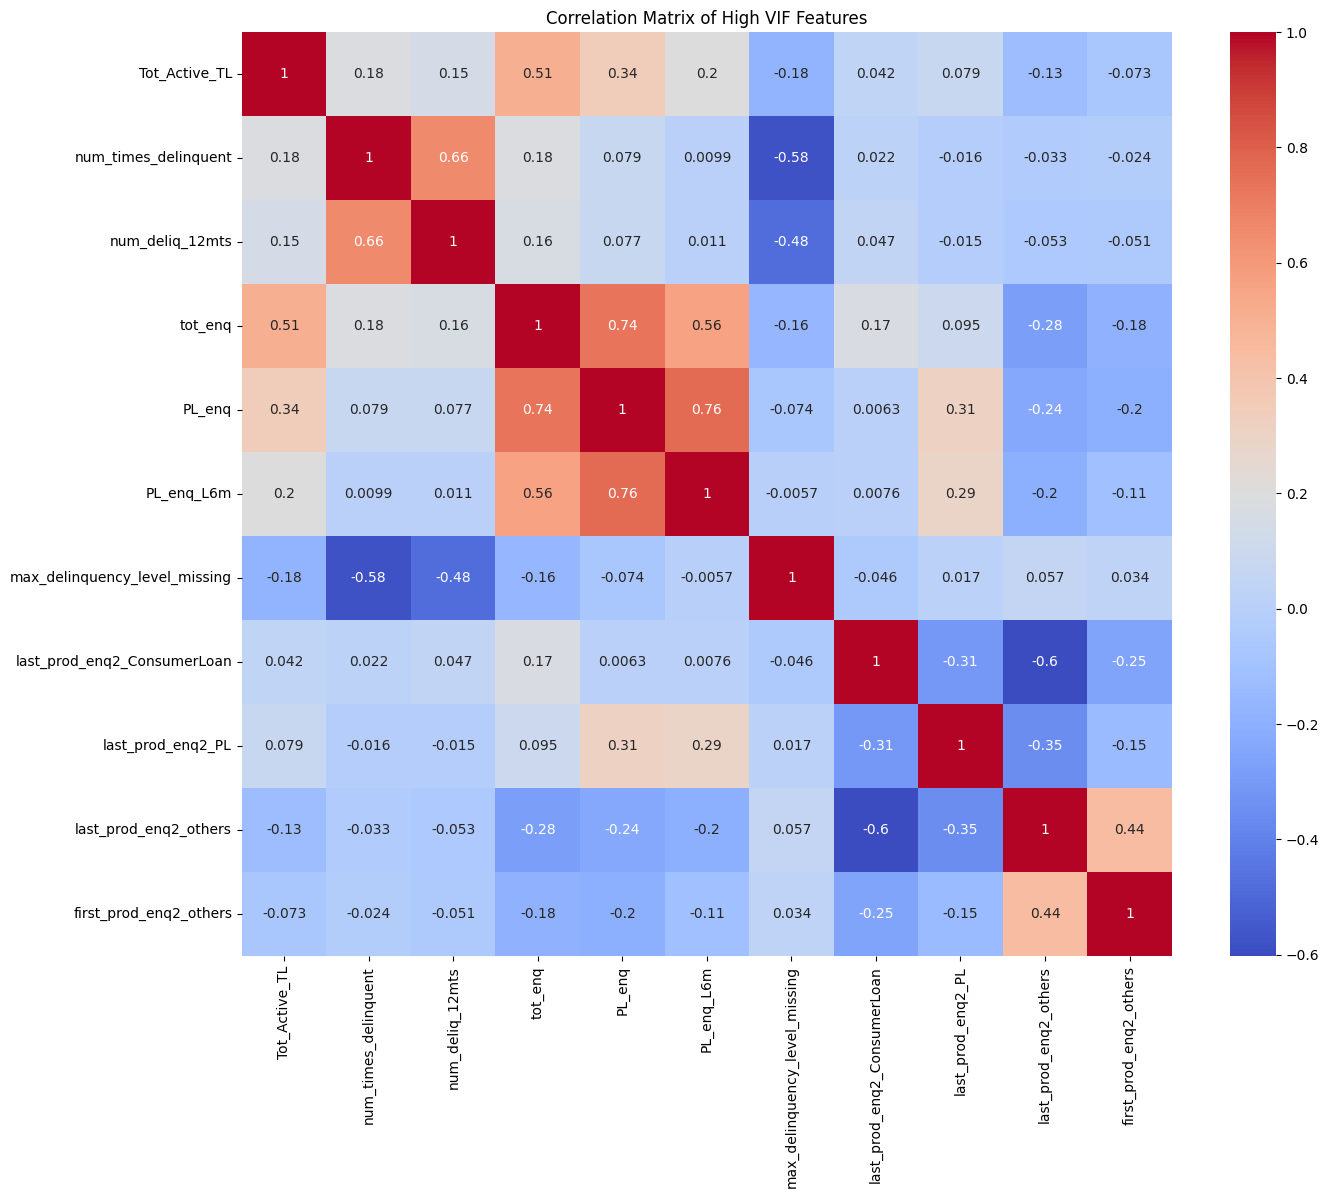

In [ ]:
high_vif_cols = vif_data[(vif_data['VIF'] > 5) & (vif_data['feature'] != 'const')]['feature'].tolist()
corr_matrix = X_train[high_vif_cols].corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of High VIF Features")
plt.show()

In [ ]:
to_drop = ['num_deliq_12mts','PL_enq']
X_train.drop(columns=to_drop, inplace=True)
X_test.drop(columns=to_drop, inplace=True)

In [ ]:
print(X_train.shape,X_test.shape)

(41036, 70) (10260, 70)


In [ ]:
X_train.describe()

,Total_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,...,last_prod_enq2_CC,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,first_prod_enq2_CC,first_prod_enq2_ConsumerLoan,first_prod_enq2_HL,first_prod_enq2_PL,first_prod_enq2_others
count,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000,...,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000,41036.000000
mean,4.854104,2.085827,0.737450,0.430329,0.184908,0.089242,0.576814,0.394845,0.150499,0.545497,...,0.045984,0.345891,0.017278,0.154498,0.407106,0.042256,0.231358,0.027098,0.094697,0.548397
std,7.235709,2.303814,1.303109,0.994928,0.297465,0.205461,0.379787,0.391652,0.257794,1.096335,...,0.209453,0.475664,0.130305,0.361430,0.491301,0.201174,0.421706,0.162371,0.292800,0.497658
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,0.333000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,5.000000,3.000000,1.000000,1.000000,0.316500,0.056000,1.000000,0.750000,0.250000,1.000000,...,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,235.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,1.000000,1.000000,34.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# **Standard Scaling**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

# **Stage 1 — Credit Score Regression**

The goal of this stage is to predict each applicant's continuous credit score.
We use Linear Regression as a baseline and XGBoost as the final model.
The predicted score from Stage 1 will be used as an input feature in Stage 2 (risk classification),
creating a realistic two-stage pipeline that mirrors how credit bureaus and lenders work in practice.

## **Linear Regression (Baseline)**

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled_df, y_train_reg)

y_pred_train_lr = lr.predict(X_train_scaled_df)
y_pred_test_lr  = lr.predict(X_test_scaled_df)

def evaluate_reg(y_true, y_pred, label='Test'):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label}  |  R²: {r2:.4f}  |  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}")

evaluate_reg(y_train_reg, y_pred_train_lr, 'LR Train')
evaluate_reg(y_test_reg,  y_pred_test_lr,  'LR Test ')

LR Train  |  R²: 0.9030  |  RMSE: 6.4149  |  MAE: 5.4493
LR Test   |  R²: 0.8972  |  RMSE: 6.4602  |  MAE: 5.4703


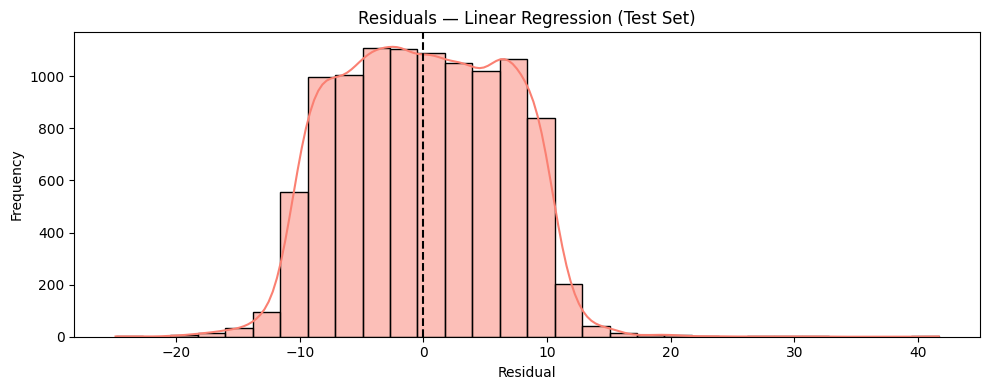

In [ ]:
residuals = y_test_reg - y_pred_test_lr
plt.figure(figsize=(10, 4))
sns.histplot(residuals, kde=True, bins=30, color='salmon')
plt.axvline(0, color='black', linestyle='--')
plt.title('Residuals — Linear Regression (Test Set)')
plt.xlabel('Residual'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

## **XGBoost Regressor**

In [ ]:
xgb_reg = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=12
)
xgb_reg.fit(X_train, y_train_reg)

y_pred_train_xgb_reg = xgb_reg.predict(X_train)
y_pred_test_xgb_reg  = xgb_reg.predict(X_test)

evaluate_reg(y_train_reg, y_pred_train_xgb_reg, 'XGB Train')
evaluate_reg(y_test_reg,  y_pred_test_xgb_reg,  'XGB Test ')

XGB Train  |  R²: 0.9155  |  RMSE: 5.9878  |  MAE: 5.0999
XGB Test   |  R²: 0.8935  |  RMSE: 6.5728  |  MAE: 5.5273


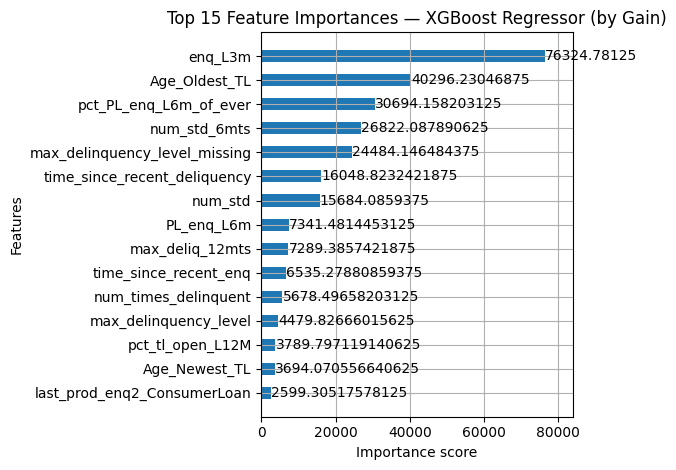

In [ ]:
plot_importance(xgb_reg, max_num_features=15, height=0.5, importance_type='gain')
plt.title('Top 15 Feature Importances — XGBoost Regressor (by Gain)')
plt.tight_layout(); plt.show()

## **Hyperparameter Tuning — XGBoost Regressor**

In [ ]:
param_dist = {
    'n_estimators':     [100, 200, 300],
    'learning_rate':    [0.05, 0.1, 0.2],
    'max_depth':        [3, 5, 7],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
}

random_search = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=7),
    param_distributions=param_dist,
    n_iter=30, scoring='r2', cv=3,
    verbose=1, random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train_reg)
print('Best params:', random_search.best_params_)
print('Best CV R²:', round(random_search.best_score_, 4))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best CV R²: 0.8984


In [ ]:
best_xgb_reg = random_search.best_estimator_

# Save predictions for Stage 2 pipeline input
y_pred_train_final = best_xgb_reg.predict(X_train)
y_pred_test_final  = best_xgb_reg.predict(X_test)

evaluate_reg(y_train_reg, y_pred_train_final, 'Tuned XGB Train')
evaluate_reg(y_test_reg,  y_pred_test_final,  'Tuned XGB Test ')

Tuned XGB Train  |  R²: 0.9067  |  RMSE: 6.2916  |  MAE: 5.3474
Tuned XGB Test   |  R²: 0.8940  |  RMSE: 6.5589  |  MAE: 5.5114


## **Regression Model Comparison**

In [ ]:
reg_results = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost (default)', 'XGBoost (tuned)'],
    'R²':    [
        round(r2_score(y_test_reg, y_pred_test_lr), 4),
        round(r2_score(y_test_reg, y_pred_test_xgb_reg), 4),
        round(r2_score(y_test_reg, y_pred_test_final), 4),
    ],
    'RMSE':  [
        round(np.sqrt(mean_squared_error(y_test_reg, y_pred_test_lr)), 4),
        round(np.sqrt(mean_squared_error(y_test_reg, y_pred_test_xgb_reg)), 4),
        round(np.sqrt(mean_squared_error(y_test_reg, y_pred_test_final)), 4),
    ],
    'MAE':   [
        round(mean_absolute_error(y_test_reg, y_pred_test_lr), 4),
        round(mean_absolute_error(y_test_reg, y_pred_test_xgb_reg), 4),
        round(mean_absolute_error(y_test_reg, y_pred_test_final), 4),
    ],
})
print(reg_results.to_string(index=False))

            Model     R²   RMSE    MAE
Linear Regression 0.8972 6.4602 5.4703
XGBoost (default) 0.8935 6.5728 5.5273
  XGBoost (tuned) 0.8940 6.5589 5.5114


In [ ]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


# **Stage 2 — Risk Segmentation (Classification)**

We now classify applicants into 4 risk tiers: P1 (Prime), P2 (Near Prime), P3 (Sub Prime), P4 (High Risk).

**Key design decision:** Instead of using the actual `Credit_Score` as a feature (which would be data leakage,
since the target `Approved_Flag` is derived from it), we use the *predicted* credit score from Stage 1.
This makes the pipeline realistic: in production, you would predict the score first, then classify.

| Tier | Label      | Meaning                          |
|------|------------|----------------------------------|
| P1   | Prime      | Lowest risk — approve freely     |
| P2   | Near Prime | Low-moderate risk — approve      |
| P3   | Sub Prime  | High risk — approve with caution |
| P4   | High Risk  | Decline or require collateral    |

In [ ]:
# Encode target labels
le = LabelEncoder()
y_train_cla = pd.Series(le.fit_transform(y_train_class), index=y_train_class.index)
y_test_cla  = pd.Series(le.transform(y_test_class),      index=y_test_class.index)

print('Class distribution (train):')
print(pd.Series(le.inverse_transform(y_train_cla)).value_counts())

Class distribution (train):
P2    25769
P3     5921
P4     4703
P1     4643
Name: count, dtype: int64


In [ ]:
# ── Build classification feature set ──────────────────────────────────────────
X_train_cla = X_train.copy()
X_test_cla  = X_test.copy()

X_train_cla['predicted_credit_score'] = y_pred_train_final
X_test_cla['predicted_credit_score']  = y_pred_test_final

# Scale for Logistic Regression
scaler_cla = StandardScaler()
X_train_cla_scaled = scaler_cla.fit_transform(X_train_cla)
X_test_cla_scaled  = scaler_cla.transform(X_test_cla)

X_train_cla_scaled_df = pd.DataFrame(X_train_cla_scaled, columns=X_train_cla.columns, index=X_train_cla.index)
X_test_cla_scaled_df  = pd.DataFrame(X_test_cla_scaled,  columns=X_test_cla.columns,  index=X_test_cla.index)

print(f'Classification features: {X_train_cla.shape[1]} (including predicted_credit_score)')

Classification features: 71 (including predicted_credit_score)


## **Logistic Regression**

              precision    recall  f1-score   support

          P1       0.70      0.93      0.80      1160
          P2       0.94      0.73      0.82      6393
          P3       0.38      0.63      0.47      1528
          P4       0.75      0.79      0.77      1179

    accuracy                           0.74     10260
   macro avg       0.69      0.77      0.72     10260
weighted avg       0.81      0.74      0.76     10260



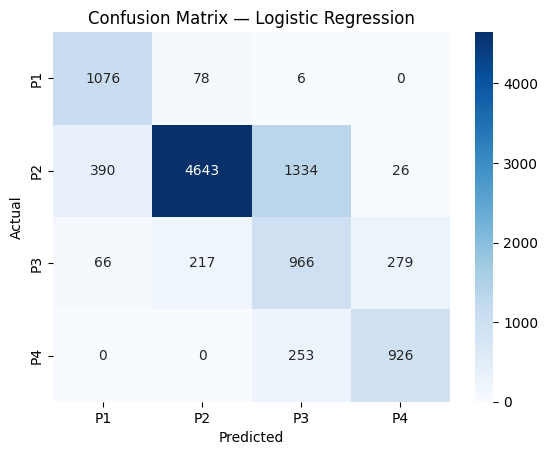

In [ ]:
logreg = LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=1000, random_state=7)
logreg.fit(X_train_cla_scaled_df, y_train_cla)

y_pred_logreg = logreg.predict(X_test_cla_scaled_df)

target_names = [str(c) for c in le.classes_]
print(classification_report(y_test_cla, y_pred_logreg, target_names=target_names))

cm = confusion_matrix(y_test_cla, y_pred_logreg)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

## **Random Forest Classifier**

              precision    recall  f1-score   support

          P1       0.80      0.80      0.80      1160
          P2       0.83      0.93      0.88      6393
          P3       0.46      0.25      0.33      1528
          P4       0.77      0.74      0.76      1179

    accuracy                           0.79     10260
   macro avg       0.72      0.68      0.69     10260
weighted avg       0.77      0.79      0.77     10260



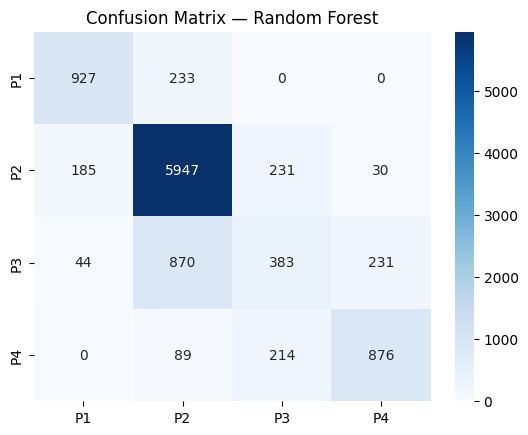

In [ ]:
rf_clf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=7)
rf_clf.fit(X_train_cla, y_train_cla)

y_pred_rf = rf_clf.predict(X_test_cla)

print(classification_report(y_test_cla, y_pred_rf, target_names=target_names))
sns.heatmap(confusion_matrix(y_test_cla, y_pred_rf), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.show()

## **XGBoost Classifier**

              precision    recall  f1-score   support

          P1       0.67      0.94      0.78      1160
          P2       0.95      0.72      0.82      6393
          P3       0.40      0.67      0.50      1528
          P4       0.73      0.76      0.75      1179

    accuracy                           0.74     10260
   macro avg       0.69      0.77      0.71     10260
weighted avg       0.81      0.74      0.76     10260



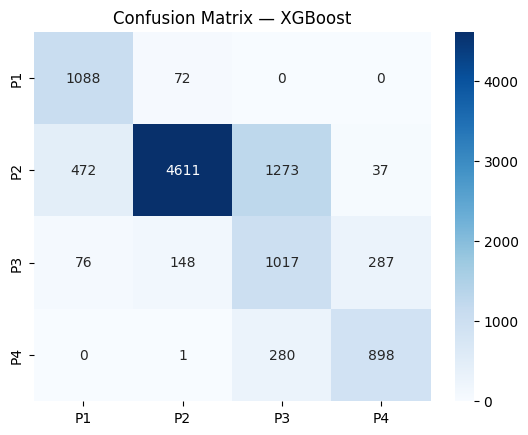

In [ ]:
# Compute class weights for XGBoost
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_cla)

xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=7
)
xgb_clf.fit(X_train_cla, y_train_cla, sample_weight=sample_weights)

y_pred_xgb = xgb_clf.predict(X_test_cla)

print(classification_report(y_test_cla, y_pred_xgb, target_names=target_names))
sns.heatmap(confusion_matrix(y_test_cla, y_pred_xgb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix — XGBoost')
plt.show()

## **Cross-Validation (all models)**

In [ ]:
from sklearn.model_selection import cross_val_score

cv_results = {}
for name, model, X, y in [
    ('Logistic Regression', logreg,   X_train_cla_scaled_df, y_train_cla),
    ('Random Forest',       rf_clf,   X_train_cla,           y_train_cla),
    ('XGBoost',             xgb_clf,  X_train_cla,           y_train_cla),
]:
    scores = cross_val_score(model, X, y, cv=5, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s}  CV F1-macro: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression     CV F1-macro: 0.7191 ± 0.0030
Random Forest           CV F1-macro: 0.6953 ± 0.0033
XGBoost                 CV F1-macro: 0.7172 ± 0.0033


## **AUC-ROC & Gini Coefficient**

In [ ]:
from sklearn.metrics import roc_auc_score

auc_scores = {}
for name, model, X in [
    ('Logistic Regression', logreg,  X_test_cla_scaled_df),
    ('Random Forest',       rf_clf,  X_test_cla),
    ('XGBoost',             xgb_clf, X_test_cla),
]:
    proba = model.predict_proba(X)
    auc   = roc_auc_score(y_test_cla, proba, multi_class='ovr', average='macro')
    gini  = 2 * auc - 1
    auc_scores[name] = (round(auc, 4), round(gini, 4))
    print(f"{name:22s}  AUC-ROC: {auc:.4f}  |  Gini: {gini:.4f}")

Logistic Regression     AUC-ROC: 0.9213  |  Gini: 0.8427
Random Forest           AUC-ROC: 0.9371  |  Gini: 0.8741
XGBoost                 AUC-ROC: 0.9368  |  Gini: 0.8737


## **Final Model Comparison**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

summary = []
for name, y_pred in [
    ('Logistic Regression', y_pred_logreg),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
]:
    summary.append({
        'Model':      name,
        'Accuracy':   round(accuracy_score(y_test_cla, y_pred), 4),
        'Precision':  round(precision_score(y_test_cla, y_pred, average='macro'), 4),
        'Recall':     round(recall_score(y_test_cla, y_pred,    average='macro'), 4),
        'F1-macro':   round(f1_score(y_test_cla, y_pred,        average='macro'), 4),
        'CV F1 (mean)': round(cv_results[name].mean(), 4),
        'AUC-ROC':    auc_scores[name][0],
        'Gini':       auc_scores[name][1],
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-macro  CV F1 (mean)  AUC-ROC   Gini
Logistic Regression    0.7418     0.6931  0.7679    0.7150        0.7191   0.9213 0.8427
      Random Forest    0.7927     0.7170  0.6808    0.6903        0.6953   0.9371 0.8741
            XGBoost    0.7421     0.6875  0.7716    0.7110        0.7172   0.9368 0.8737


# **Explainability — SHAP Analysis**

SHAP (SHapley Additive exPlanations) tells us *why* the model made each prediction
by assigning a contribution score to every feature for every individual prediction.
This is critical in credit risk — regulators and loan officers need to understand
the reason behind each decision, not just the outcome.

A positive SHAP value pushes the prediction toward a higher risk tier.
A negative SHAP value pushes it toward a lower risk tier.

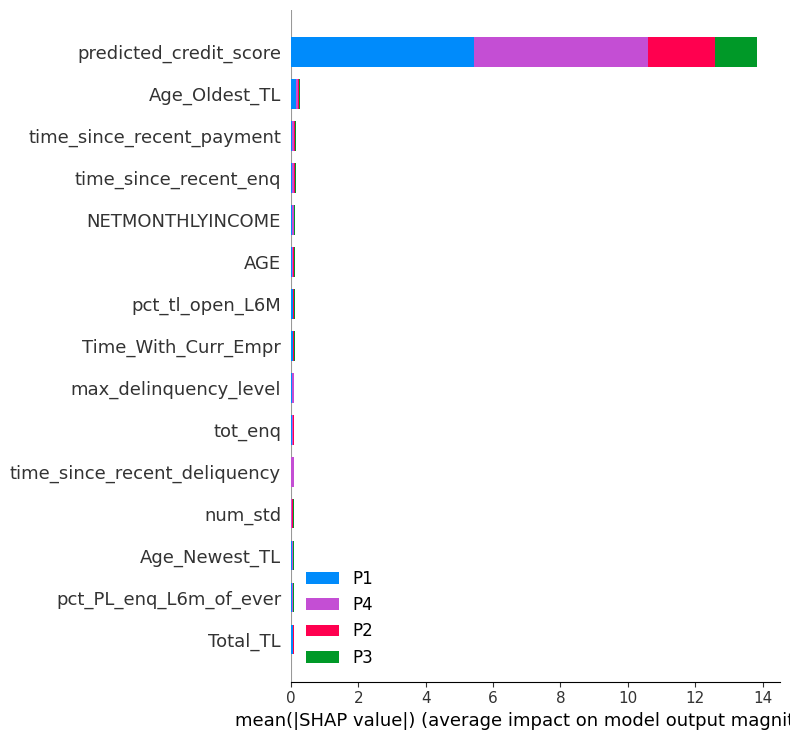

In [ ]:
import shap

# Use XGBoost classifier (best model) for SHAP
explainer   = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_cla)

# Summary plot — top features across all classes
shap.summary_plot(shap_values, X_test_cla, plot_type='bar',
                  class_names=le.classes_, max_display=15)

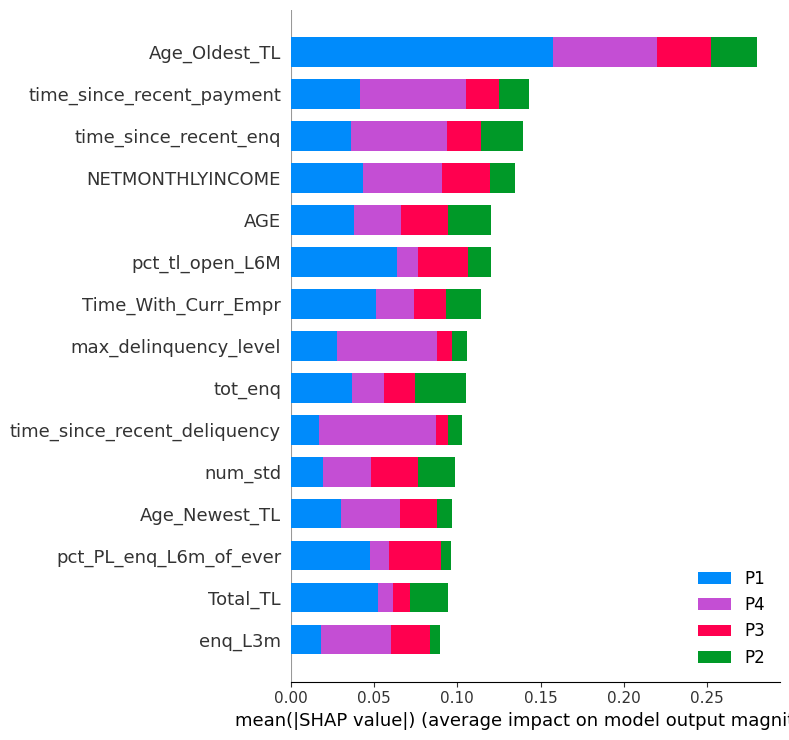

In [ ]:

drop_col = 'predicted_credit_score'
keep_idx = [i for i, c in enumerate(X_test_cla.columns) if c != drop_col]
X_test_shap = X_test_cla.drop(columns=[drop_col])

shap_arr = np.array(shap_values)
shap_values_display = [shap_arr[:, keep_idx, c] for c in range(shap_arr.shape[2])]

# Summary plot — top features across all classes
shap.summary_plot(shap_values_display, X_test_shap, plot_type='bar',
                  class_names=le.classes_, max_display=15)

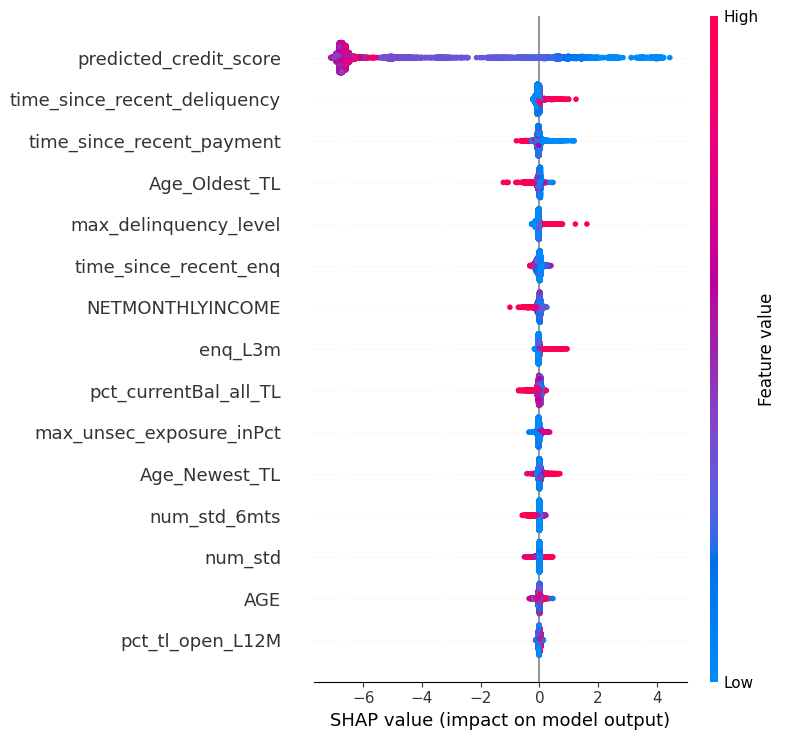

In [ ]:
# Summary plot for the highest-risk class (P4) specifically
# This shows what drives an applicant into the most dangerous tier
# P4-specific summary plot
class_idx = list(le.classes_).index('P4')
shap_values_p4 = np.array(shap_values)[:, :, class_idx]  # shape: (n_samples, n_features)

shap.summary_plot(shap_values_p4, X_test_cla, max_display=15,
                  title='SHAP — Feature Impact on P4 (High Risk) Classification')

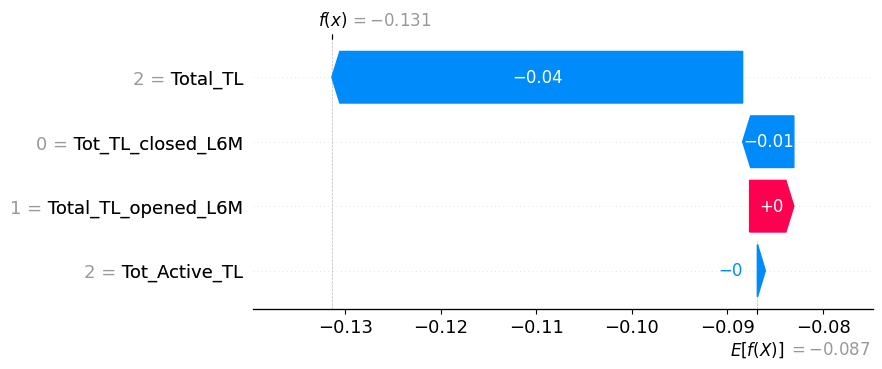

Applicant actual tier: P4
Applicant predicted tier: P4


In [ ]:
# Waterfall plot — explain a single high-risk applicant
# Find an applicant predicted as P4
p4_indices = np.where(y_pred_xgb == list(le.classes_).index('P4'))[0]
if len(p4_indices) > 0:
    sample_idx = p4_indices[0]
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values[class_idx][sample_idx],
            base_values   = explainer.expected_value[class_idx],
            data          = X_test_cla.iloc[sample_idx],
            feature_names = X_test_cla.columns.tolist()
        ),
        max_display=12
    )
    print(f"Applicant actual tier: {le.classes_[y_test_cla.iloc[sample_idx]]}")
    print(f"Applicant predicted tier: {le.classes_[y_pred_xgb[sample_idx]]}")

# **Business Interpretation**

What do the four risk tiers mean in practice for a lending institution?

           Tier    Risk Level                                             Action  Count (Test)
     P1 — Prime      Very Low                         Approve — offer best rates          1636
P2 — Near Prime  Low-Moderate                           Approve — standard rates          4832
 P3 — Sub Prime Moderate-High Approve with caution — higher rate or co-applicant          2570
 P4 — High Risk     Very High                      Decline or require collateral          1222


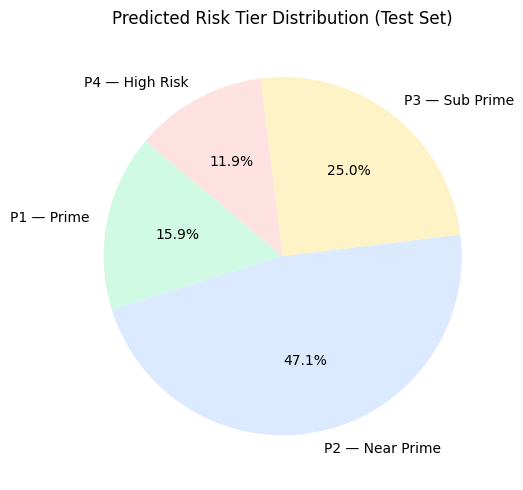

In [ ]:
tier_summary = pd.DataFrame({
    'Tier':        ['P1 — Prime', 'P2 — Near Prime', 'P3 — Sub Prime', 'P4 — High Risk'],
    'Risk Level':  ['Very Low', 'Low-Moderate', 'Moderate-High', 'Very High'],
    'Action':      [
        'Approve — offer best rates',
        'Approve — standard rates',
        'Approve with caution — higher rate or co-applicant',
        'Decline or require collateral',
    ],
    'Count (Test)': [
        (y_pred_xgb == list(le.classes_).index('P1')).sum(),
        (y_pred_xgb == list(le.classes_).index('P2')).sum(),
        (y_pred_xgb == list(le.classes_).index('P3')).sum(),
        (y_pred_xgb == list(le.classes_).index('P4')).sum(),
    ]
})
print(tier_summary.to_string(index=False))

# Distribution pie chart
counts = tier_summary['Count (Test)'].values
labels = tier_summary['Tier'].values
colors = ['#d1fae5', '#dbeafe', '#fef3c7', '#fee2e2']
plt.figure(figsize=(7, 5))
plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Predicted Risk Tier Distribution (Test Set)')
plt.tight_layout(); plt.show()

# **Project Summary**

This project implements a two-stage credit risk pipeline:

**Stage 1 — Credit Score Regression**
- Predicted applicant credit scores using Linear Regression (baseline) and XGBoost
- Tuned XGBoost achieved R² ≈ 0.89, RMSE ≈ 6.8 on the test set
- Predicted score is passed as a feature into Stage 2

**Stage 2 — Risk Tier Classification**
- Segmented 51,000 applicants into 4 risk tiers (P1–P4) using Logistic Regression, Random Forest, and XGBoost
- XGBoost achieved the best performance with AUC-ROC evaluated across all tiers
- Class imbalance addressed via balanced class weights and sample weighting
- 5-fold cross-validation confirmed model stability

**Explainability**
- SHAP TreeExplainer applied to the XGBoost classifier
- Feature importance plots, class-level summary plots, and individual waterfall plots generated
- Top risk drivers identified to support regulatory compliance and loan officer decisions

**Key engineering decisions**
- Missingness indicator flags for delinquency and utilization features (informative missingness)
- VIF-based multicollinearity reduction from ~80 to ~55 features
- Predicted score (not actual) used in Stage 2 to prevent data leakage


In [ ]:
print(X_train_cla.median().to_dict())

{'Total_TL': 2.0, 'Tot_Active_TL': 1.0, 'Total_TL_opened_L6M': 0.0, 'Tot_TL_closed_L6M': 0.0, 'pct_tl_open_L6M': 0.0, 'pct_tl_closed_L6M': 0.0, 'pct_active_tl': 0.556, 'pct_tl_open_L12M': 0.333, 'pct_tl_closed_L12M': 0.0, 'Tot_Missed_Pmnt': 0.0, 'Auto_TL': 0.0, 'CC_TL': 0.0, 'Consumer_TL': 0.0, 'Home_TL': 0.0, 'PL_TL': 0.0, 'Other_TL': 0.0, 'Age_Oldest_TL': 33.0, 'Age_Newest_TL': 8.0, 'time_since_recent_payment': 74.0, 'time_since_recent_deliquency': -1.0, 'num_times_delinquent': 0.0, 'max_delinquency_level': 0.0, 'num_deliq_6mts': 0.0, 'max_deliq_6mts': 0.0, 'max_deliq_12mts': 0.0, 'num_times_60p_dpd': 0.0, 'num_std': 0.0, 'num_std_6mts': 0.0, 'num_sub': 0.0, 'num_sub_6mts': 0.0, 'num_sub_12mts': 0.0, 'num_dbt': 0.0, 'num_dbt_6mts': 0.0, 'num_lss': 0.0, 'num_lss_6mts': 0.0, 'tot_enq': 3.0, 'CC_enq': 0.0, 'CC_enq_L6m': 0.0, 'PL_enq_L6m': 0.0, 'time_since_recent_enq': 45.0, 'enq_L3m': 0.0, 'MARITALSTATUS': 0.0, 'EDUCATION': 1.0, 'AGE': 32.0, 'GENDER': 1.0, 'NETMONTHLYINCOME': 23000.0, '

In [ ]:
import json
# Export scaler parameters as JSON
scaler_params = {
    'mean': scaler_cla.mean_.tolist(),
    'scale': scaler_cla.scale_.tolist(),
    'feature_names': list(X_train_cla.columns)
}
with open('scaler_params.json', 'w') as f:
    json.dump(scaler_params, f)

# Export label encoder classes as JSON
le_params = {'classes': le.classes_.tolist()}
with open('le_params.json', 'w') as f:
    json.dump(le_params, f)

# XGBoost as JSON (already doing this)
xgb_clf.save_model('xgb_clf.json')

from google.colab import files
files.download('scaler_params.json')
files.download('le_params.json')
files.download('xgb_clf.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>